# Direcciones on a map (Folium)

Requires: `pandas`, `folium`, `geopy`. Geocoding uses OpenStreetMap Nominatim (about one request per second; results are cached under `data/`).


In [22]:
from __future__ import annotations

import html
import json
import time
from pathlib import Path

import folium
import pandas as pd
from folium.plugins import MarkerCluster
from geopy.extra.rate_limiter import RateLimiter
from geopy.geocoders import Nominatim

In [23]:
# Plot all geocoded clients in an interactive Folium map.
# The map is centered on the median coordinate and uses clustering for readability.

candidate_paths = [
    Path("../data/custom/geo/geocoded_direcciones.csv"),
    Path("data/custom/geo/geocoded_direcciones.csv"),
    Path("../data/geocoded_direcciones.csv"),
    Path("data/geocoded_direcciones.csv"),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find geocoded_direcciones.csv. Checked: "
        + ", ".join(str(p) for p in candidate_paths)
    )

# Some rows can be malformed; skip bad lines to keep notebook execution smooth.
df = pd.read_csv(csv_path, engine="python", on_bad_lines="skip")

required_columns = {"query", "lat", "lon"}
missing = required_columns.difference(df.columns)
if missing:
    raise ValueError(f"Missing columns in {csv_path}: {sorted(missing)}")

# Keep only valid coordinates.
geo_df = df.dropna(subset=["lat", "lon"]).copy()
geo_df["lat"] = pd.to_numeric(geo_df["lat"], errors="coerce")
geo_df["lon"] = pd.to_numeric(geo_df["lon"], errors="coerce")
geo_df = geo_df.dropna(subset=["lat", "lon"])

if geo_df.empty:
    raise ValueError("No valid geocoded rows found after filtering.")

# Remove duplicate points before plotting.
# Rounded coordinates avoid tiny floating-point differences counting as unique points.
geo_df["query"] = geo_df["query"].fillna("").astype(str).str.strip()
before_dedup = len(geo_df)
geo_df = (
    geo_df.assign(lat_6=geo_df["lat"].round(6), lon_6=geo_df["lon"].round(6))
    .drop_duplicates(subset=["query", "lat_6", "lon_6"])
    .drop(columns=["lat_6", "lon_6"])
)
duplicates_removed = before_dedup - len(geo_df)

center_lat = geo_df["lat"].median()
center_lon = geo_df["lon"].median()

m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles="CartoDB Positron")
cluster = MarkerCluster(name="Clients").add_to(m)

for row in geo_df.itertuples(index=False):
    popup_text = html.escape(str(row.query))
    folium.CircleMarker(
        location=[row.lat, row.lon],
        radius=3,
        weight=1,
        color="#1f77b4",
        fill=True,
        fill_opacity=0.75,
        popup=folium.Popup(popup_text, max_width=380),
    ).add_to(cluster)

folium.LayerControl(collapsed=False).add_to(m)

print(f"Loaded {len(df):,} rows from {csv_path}")
print(f"Valid geocoded rows: {before_dedup:,}")
print(f"Duplicates removed: {duplicates_removed:,}")
print(f"Plotted unique clients: {len(geo_df):,}")

m

Loaded 1,166 rows from ../data/custom/geo/geocoded_direcciones.csv
Valid geocoded rows: 1,161
Duplicates removed: 0
Plotted unique clients: 1,161


## Detalle_entrega.csv breakdown charts

These cells load `Detalle_entrega.csv` and generate quick exploratory visuals.

In [24]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

candidate_detalle_paths = [
    Path("../data/csv/Hackaton/Detalle_entrega.csv"),
    Path("data/csv/Hackaton/Detalle_entrega.csv"),
]

detalle_path = next((p for p in candidate_detalle_paths if p.exists()), None)
if detalle_path is None:
    raise FileNotFoundError(
        "Could not find Detalle_entrega.csv. Checked: "
        + ", ".join(str(p) for p in candidate_detalle_paths)
    )

detalle_df = pd.read_csv(detalle_path, low_memory=False)
detalle_df["FECHA_dt"] = pd.to_datetime(detalle_df["FECHA"], dayfirst=True, errors="coerce")
detalle_df["Cantidad entrega"] = pd.to_numeric(detalle_df["Cantidad entrega"], errors="coerce")

print(f"Loaded {len(detalle_df):,} rows from {detalle_path}")
print(f"Date range: {detalle_df['FECHA_dt'].min().date()} to {detalle_df['FECHA_dt'].max().date()}")

Loaded 82,849 rows from ../data/csv/Hackaton/Detalle_entrega.csv
Date range: 2026-01-30 to 2026-03-31


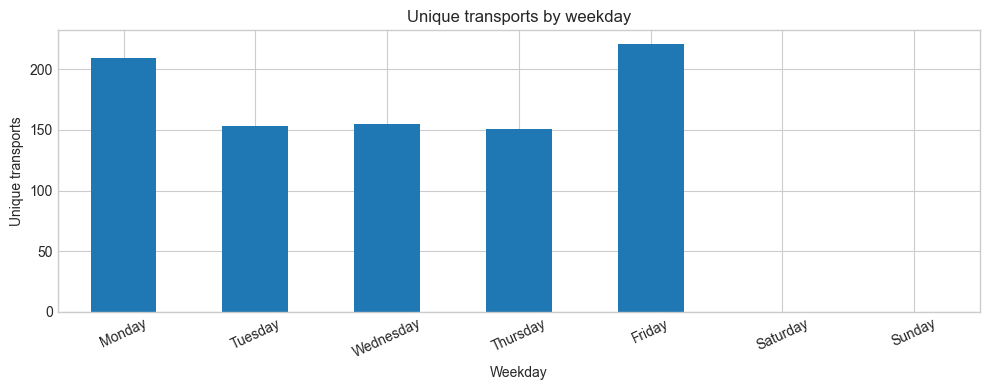

In [25]:
# 1) Weekly transport pattern (unique transports)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

transport_by_day = (
    detalle_df.dropna(subset=["FECHA_dt"])
    .assign(weekday=lambda d: d["FECHA_dt"].dt.day_name())
    .groupby("weekday")["Transporte"]
    .nunique()
    .reindex(weekday_order)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 4))
transport_by_day.plot(kind="bar", ax=ax, color="#1f77b4")
ax.set_title("Unique transports by weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Unique transports")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

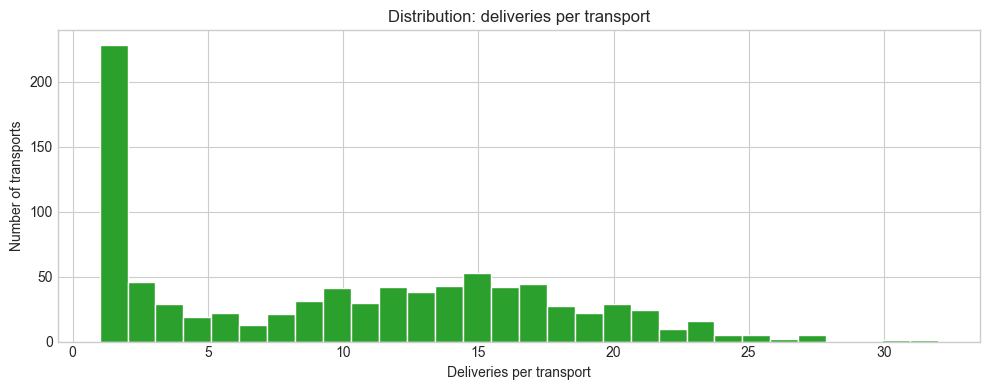

count    889.000000
mean      10.041620
std        7.237404
min        1.000000
25%        2.000000
50%       10.000000
75%       16.000000
90%       20.000000
max       32.000000


In [26]:
# 2) Distribution of deliveries per transport
deliveries_per_transport = detalle_df.groupby("Transporte")["Entrega"].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(deliveries_per_transport, bins=30, color="#2ca02c", edgecolor="white")
ax.set_title("Distribution: deliveries per transport")
ax.set_xlabel("Deliveries per transport")
ax.set_ylabel("Number of transports")
plt.tight_layout()
plt.show()

print(deliveries_per_transport.describe(percentiles=[0.25, 0.5, 0.75, 0.9]).to_string())

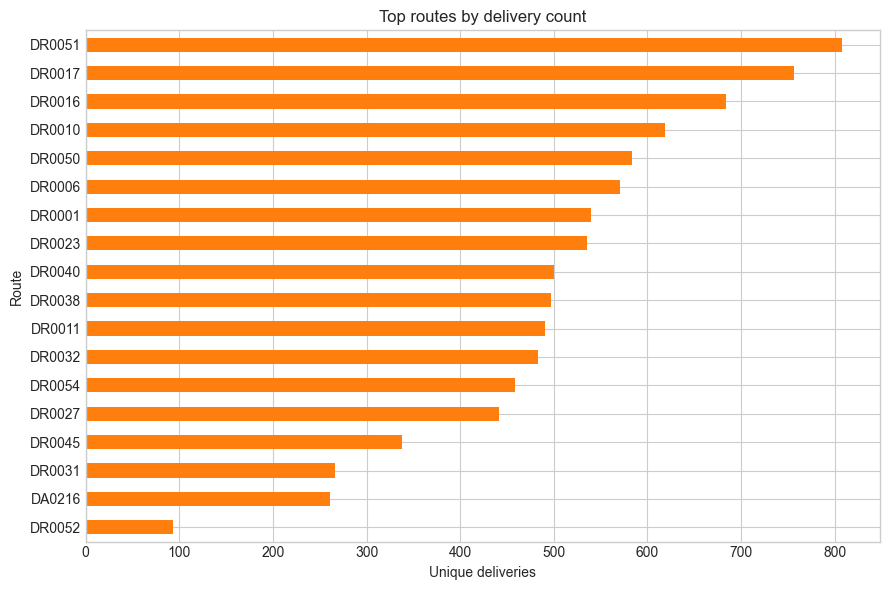

In [27]:
# 3) Top routes by number of unique deliveries
route_deliveries = (
    detalle_df.groupby("Ruta")["Entrega"]
    .nunique()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
route_deliveries.plot(kind="barh", ax=ax, color="#ff7f0e")
ax.set_title("Top routes by delivery count")
ax.set_xlabel("Unique deliveries")
ax.set_ylabel("Route")
plt.tight_layout()
plt.show()

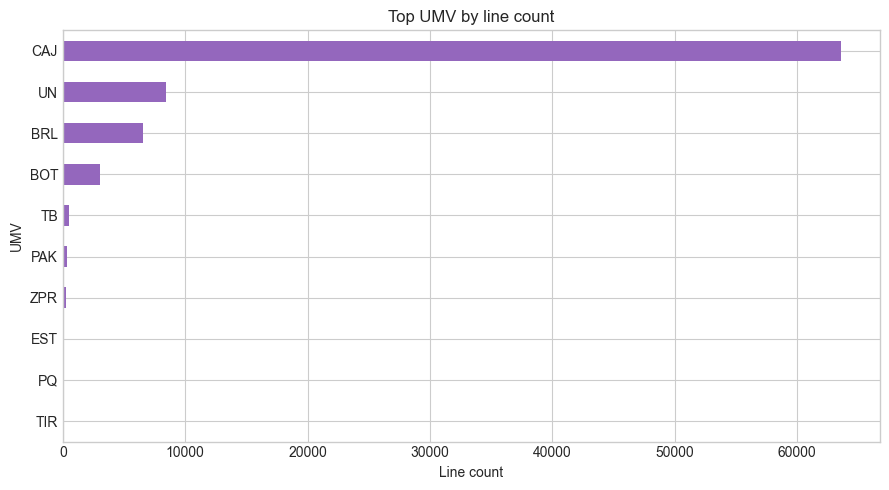

Top UMV share (%):
Un.medida venta
CAJ    76.78
UN     10.16
BRL     7.91
BOT     3.64
TB      0.59
PAK     0.45
ZPR     0.31
EST     0.14
PQ      0.01
TIR     0.01


In [28]:
# 4) UMV line mix (top)
umv_counts = (
    detalle_df["Un.medida venta"]
    .fillna("NA")
    .value_counts()
)

top_umv = umv_counts.head(10).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
top_umv.plot(kind="barh", ax=ax, color="#9467bd")
ax.set_title("Top UMV by line count")
ax.set_xlabel("Line count")
ax.set_ylabel("UMV")
plt.tight_layout()
plt.show()

umv_share = (umv_counts / umv_counts.sum() * 100).head(10)
print("Top UMV share (%):")
print(umv_share.round(2).to_string())

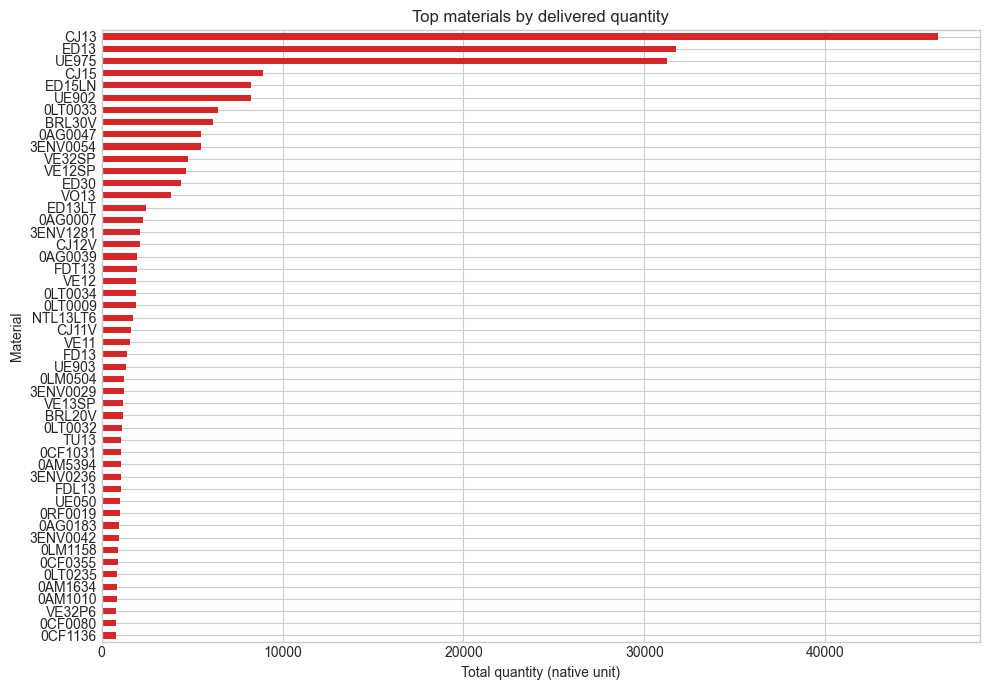

In [31]:
# 5) Top materials by delivered quantity
material_qty = (
    detalle_df.groupby("Material")["Cantidad entrega"]
    .sum(min_count=1)
    .dropna()
    .sort_values(ascending=False)
    .head(50)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
material_qty.plot(kind="barh", ax=ax, color="#d62728")
ax.set_title("Top materials by delivered quantity")
ax.set_xlabel("Total quantity (native unit)")
ax.set_ylabel("Material")
plt.tight_layout()
plt.show()

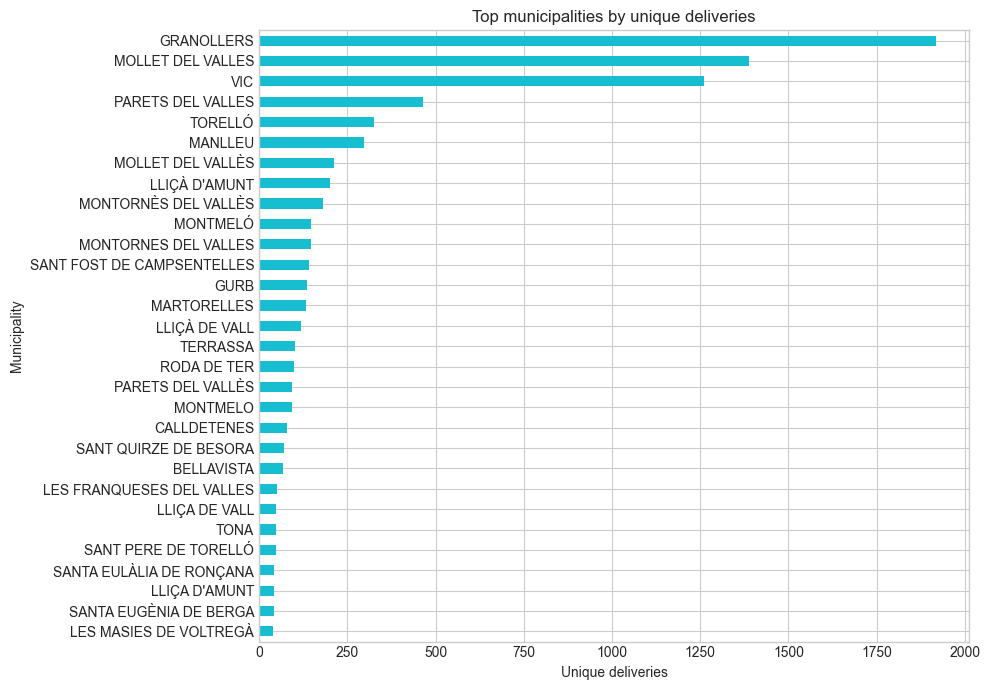

In [32]:
# 6) Top municipalities by delivery count
municipality_deliveries = (
    detalle_df.groupby("Población")["Entrega"]
    .nunique()
    .sort_values(ascending=False)
    .head(30)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
municipality_deliveries.plot(kind="barh", ax=ax, color="#17becf")
ax.set_title("Top municipalities by unique deliveries")
ax.set_xlabel("Unique deliveries")
ax.set_ylabel("Municipality")
plt.tight_layout()
plt.show()